# Preprocess drilling datasets

Формирует `datasets/united.csv`.

Финальный `united.csv` теперь сохраняет:

```text
d_depth
d_time
```

Это позволяет дальше не пересчитывать интервалы по `depth/depth_m` и убрать путаницу с глубиной в следующих notebook.


In [1]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

sys.path.append(str(Path().resolve().parent))
from config import DATASETS_DIR

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)

MIN_WELL_RECORDS = 50
D_DEPTH_UPPER = 0.3
ROTATION_LOWER = 50
ROTATION_UPPER = 250
SPEED_LOWER = 0.001
SPEED_UPPER = 0.04


In [2]:
df1 = pd.read_csv(DATASETS_DIR / "dataset_1.csv")
df2 = pd.read_csv(DATASETS_DIR / "dataset_2.csv")

common_cols = df1.columns.intersection(df2.columns)
df1 = df1[common_cols].copy()
df2 = df2[common_cols].copy()

print("dataset_1:", df1.shape)
print("dataset_2:", df2.shape)
print("Common columns:", len(common_cols))


dataset_1: (165966, 34)
dataset_2: (272961, 34)
Common columns: 34


In [3]:
# dataset_2: depth/d_depth correction used in the current pipeline.
# The notebook intentionally fails if required columns are absent.

df2 = df2.sort_values(["well_id", "time"]).reset_index(drop=True)
df2["d_depth"] = df2.groupby("well_id")["depth"].diff()
df2 = df2.dropna(subset=["d_depth"]).copy()
df2 = df2[df2["d_depth"] > 0].copy()

df2["speed"] = df2["d_depth"] / df2["d_time"]
df2["EI"] = (
    df2["pressure_axis"]
    * df2["pressure_rotation"]
    * df2["rotation"]
    / df2["speed"]
)

df1["source"] = "df1"
df2["source"] = "df2"

common_cols = [c for c in df1.columns if c in df2.columns]
df = pd.concat([df1[common_cols], df2[common_cols]], ignore_index=True)

df["time"] = pd.to_datetime(df["time"])
df["processing_time"] = pd.to_datetime(df["processing_time"])

print("Combined:", df.shape)
print("Wells:", df["well_id"].nunique())


Combined: (437510, 35)
Wells: 2071


In [4]:
def preprocess(frame: pd.DataFrame) -> tuple[pd.DataFrame, pd.DataFrame]:
    steps = []

    def add_step(name: str, data: pd.DataFrame):
        steps.append({
            "step": name,
            "rows": len(data),
            "wells": data["well_id"].nunique(),
        })

    data = frame.copy()
    add_step("initial_combined", data)

    data = data.replace([np.inf, -np.inf], np.nan)
    data = data.dropna(subset=["speed", "EI", "d_depth", "d_time"]).copy()
    data = data[(data["speed"] > 0) & (data["EI"] > 0) & (data["d_time"] > 0)].copy()
    add_step("valid_speed_EI_d_depth_d_time", data)

    data = data[(data["d_depth"] > 0) & (data["d_depth"] <= D_DEPTH_UPPER)].copy()
    add_step(f"0_lt_d_depth_le_{D_DEPTH_UPPER}", data)

    data = data[(data["rotation"] >= ROTATION_LOWER) & (data["rotation"] <= ROTATION_UPPER)].copy()
    add_step(f"rotation_{ROTATION_LOWER}_{ROTATION_UPPER}", data)

    data = data[(data["speed"] >= SPEED_LOWER) & (data["speed"] <= SPEED_UPPER)].copy()
    add_step(f"speed_{SPEED_LOWER}_{SPEED_UPPER}", data)

    well_sizes = data.groupby("well_id").size()
    valid_wells = well_sizes[well_sizes >= MIN_WELL_RECORDS].index
    data = data[data["well_id"].isin(valid_wells)].copy()
    add_step(f"wells_ge_{MIN_WELL_RECORDS}_rows", data)

    report = pd.DataFrame(steps)
    report["removed_from_prev"] = report["rows"].shift(1) - report["rows"]
    report["removed_from_prev_pct"] = report["removed_from_prev"] / report["rows"].shift(1) * 100

    return data, report


df_cleaned, filter_report = preprocess(df)

display(filter_report)
print("Cleaned:", df_cleaned.shape)
print("Wells:", df_cleaned["well_id"].nunique())


,step,rows,wells,removed_from_prev,removed_from_prev_pct
0,initial_combined,437510,2071,NaN,NaN
1,valid_speed_EI_d_depth_d_time,437080,2058,430.0,0.098283
2,0_lt_d_depth_le_0.3,430175,2049,6905.0,1.579802
3,rotation_50_250,422885,2024,7290.0,1.694659
4,speed_0.001_0.04,418588,2019,4297.0,1.016115
5,wells_ge_50_rows,415049,1706,3539.0,0.845461


Cleaned: (415049, 35)
Wells: 1706


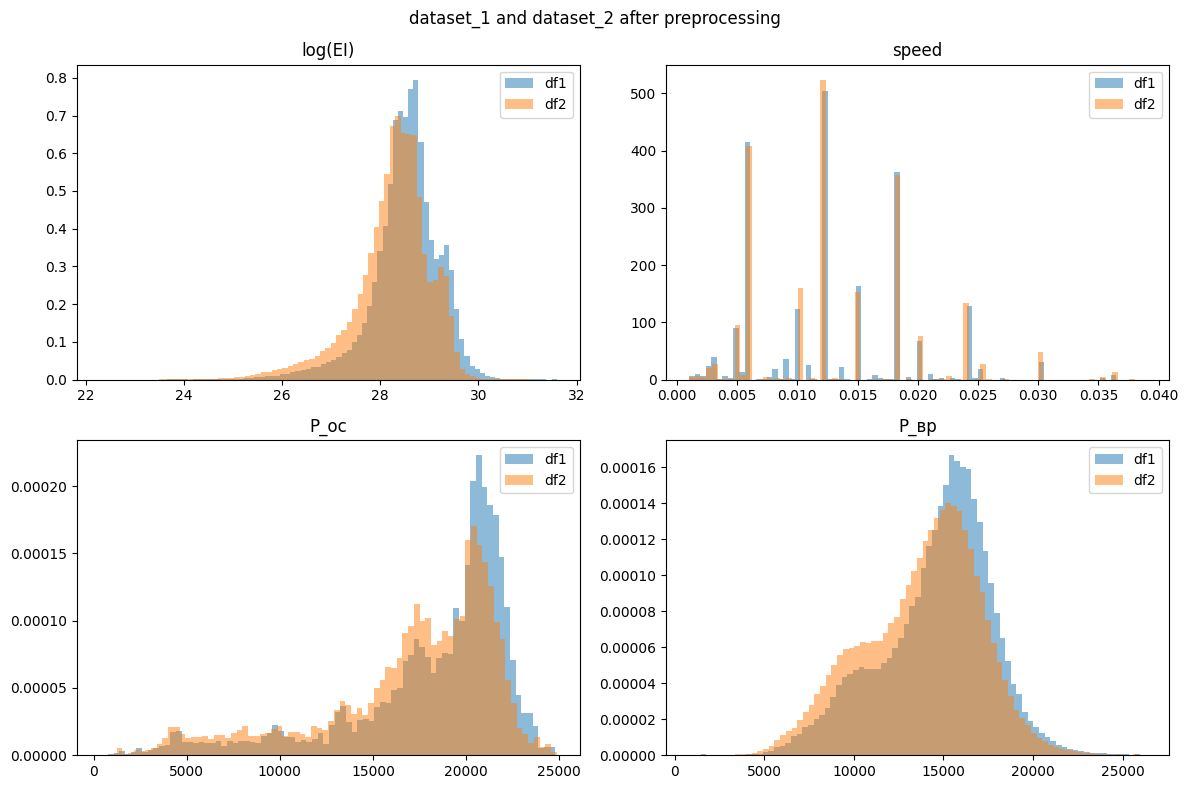

In [5]:
df_cleaned["log_EI"] = np.log1p(df_cleaned["EI"])

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

cols = ["log_EI", "speed", "pressure_axis", "pressure_rotation"]
titles = ["log(EI)", "speed", "P_ос", "P_вр"]
xlims = [None, (0, 0.05), None, None]

for ax, col, title, xlim in zip(axes, cols, titles, xlims):
    d1 = df_cleaned.loc[df_cleaned["source"] == "df1", col]
    d2 = df_cleaned.loc[df_cleaned["source"] == "df2", col]

    if xlim:
        d1 = d1.clip(*xlim)
        d2 = d2.clip(*xlim)

    ax.hist(d1, bins=80, alpha=0.5, density=True, label="df1")
    ax.hist(d2, bins=80, alpha=0.5, density=True, label="df2")
    ax.set_title(title)
    ax.legend()

plt.suptitle("dataset_1 and dataset_2 after preprocessing")
plt.tight_layout()
plt.show()


In [6]:
cols_to_drop = [
    "id",
    "time",
    "lon",
    "lat",
    "height",
    "course",
    "angle",
    "num_sattelites",
    "moving_type",
    "rod_change",
    "pressure_air",
    "electric_rotation",
    "electric_pressure_axis",
    "voltage_rotation",
    "voltage_pressure_axis",
    "time_stamp",
    "sequence_id",
    "block_well_id",
    "rig_id",
    "drilling_speed",
    "rtk_status",
    "EI 0-1",
    "EI 1-2",
    "n/p",
    "EI",
    "source",
    "log_EI",
]

df_united = df_cleaned.drop(columns=cols_to_drop, errors="ignore").copy()

# d_depth and d_time are intentionally kept.
front_cols = [
    "processing_time",
    "depth",
    "d_depth",
    "d_time",
    "rotation",
    "pressure_axis",
    "pressure_rotation",
    "well_id",
    "speed",
]
remaining_cols = [c for c in df_united.columns if c not in front_cols]
df_united = df_united[front_cols + remaining_cols]

df_united.to_csv(DATASETS_DIR / "united.csv", index=False)

print("Saved:", DATASETS_DIR / "united.csv")
print("Shape:", df_united.shape)
print("Wells:", df_united["well_id"].nunique())
print("Columns:", list(df_united.columns))
display(df_united.head())


Saved: C:\Users\qa1ro\OneDrive\Рабочий стол\diploma\OptimalDrilling\datasets\united.csv
Shape: (415049, 9)
Wells: 1706
Columns: ['processing_time', 'depth', 'd_depth', 'd_time', 'rotation', 'pressure_axis', 'pressure_rotation', 'well_id', 'speed']


,processing_time,depth,d_depth,d_time,rotation,pressure_axis,pressure_rotation,well_id,speed
1,2025-10-07 22:18:14.495,4.6965,0.1212,6.0,104.892,12781,13144,25512,0.02020
2,2025-10-07 22:18:19.239,4.8783,0.1818,5.0,101.430,18971,18936,25512,0.03636
3,2025-10-07 22:18:24.208,5.0298,0.1515,5.0,101.430,20153,18184,25512,0.03030
4,2025-10-07 22:18:29.385,5.1813,0.1515,5.0,102.714,20162,17445,25512,0.03030
8,2025-10-07 22:19:22.224,6.0297,0.1212,5.0,103.110,18591,19741,25512,0.02424
